In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [110]:
text = open('/Users/khakim/summer-ML/summer-ML/step-1/input.txt').read()

alph =  sorted(list(set(text)))
alph_size = len(alph)
stoi = {c: i for i, c in enumerate(alph)}
itos = {v: k for k, v in stoi.items()}
encode = lambda x: [stoi[c] for c in x]
decode = lambda x: ''.join([itos[ic] for ic in x])
n = int(0.9 * len(text))
Xtr = encode(text[:n])
Xval = encode(text[n:])

In [111]:
gen = torch.Generator().manual_seed(42)
embed_size = 32
num_head = 4
head_size = embed_size // num_head
num_blocks = 4
batch_size = 4
block_size = 8

In [112]:
gen = torch.Generator().manual_seed(42)
def getbatch(X):
    starts = torch.randint(0, len(X) - block_size, (batch_size,), generator = gen)
    context = torch.tensor([X[st : st + block_size] for st in starts])
    return context

In [ ]:
class FeedForward(nn.Module):

    def __init__(self, embed_size):
        super().__init__()
        self.lin1 = nn.Linear(embed_size, embed_size * 4)
        self.act = nn.GELU()
        self.lin2 = nn.Linear(embed_size * 4, embed_size)
    
    def forward(self, x):
        # (batch_size, block_size, embed_size)
        return self.lin2(self.act(self.lin1(x)))


class Block(nn.Module):

    def __init__(self, block_size, embed_size, num_head): # no need in block_size, as no mask used!
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_size)
        self.attn = nn.MultiheadAttention(embed_size, num_head, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_size)
        self.ff = FeedForward(embed_size)
    
    def forward(self, x):
        # (batch_size, block_size, embed_size)
        attn_in = self.norm1(x)
        x = x + self.attn(key = attn_in, query = attn_in, value = attn_in)[0]
        x = x + self.ff(self.norm2(x))
        return x
    

class BERT(nn.Module):
    
    def __init__(self, block_size, vocab_size, embed_size, num_head, num_blocks):
        super().__init__()
        self.block_size = block_size
        self.embedding = nn.Embedding(vocab_size + 1, embed_size) # +1 because of the [MASK] token
        self.pos_embedding = nn.Embedding(block_size, embed_size)
        self.blocks = nn.Sequential(*[Block(block_size, embed_size, num_head) for _ in range(num_blocks)])
        self.norm = nn.LayerNorm(embed_size)
        self.linear = nn.Linear(embed_size, vocab_size) # not vocab_size + 1, because don't want to predict [MASK] token
    
    def forward(self, x):
        # (batch_size, block_size) numbers from zero to vocab_size
        x_embed = self.embedding(x)
        pos_embed = self.pos_embedding(torch.arange(x.shape[-1]))
        x_embed = x_embed + pos_embed
        x_out = self.blocks(x_embed)
        norm_x_out = self.norm(x_out)
        logits = self.linear(norm_x_out)
        return logits
    

class Masking(nn.Module):

    def __init__(self, mask_token_id, masked_percent = 0.15):
        super().__init__()
        self.masked_percent = masked_percent
        self.mask_token_id = mask_token_id

    @torch.no_grad()
    def forward(self, x):
        B, L = x.shape
        y = x.clone()
        mask_size = int(L * self.masked_percent)

        rand_scores = torch.rand(B, L, generator=gen)
        masked_idx = rand_scores.argsort(dim=1)[:, :mask_size]  # (B, mask_size)

        mask = torch.zeros(B, L, dtype=torch.bool)
        mask.scatter_(1, masked_idx, True)

        y[mask] = self.mask_token_id
        return y, mask


In [114]:
model = BERT(block_size, alph_size, embed_size, num_head, num_blocks)
masker = Masking(alph_size, masked_percent = 0.15)

In [118]:
@torch.no_grad()
def getloss(X, num):
    sumloss = 0
    for _ in range(num):
        x = getbatch(X)
        masked_x, mask = masker(x)
        logits = model(masked_x)
        loss = F.cross_entropy(logits[mask].view(-1, alph_size), x[mask].view(-1))
        sumloss += loss
    return sumloss / num

In [119]:
lossi = []

In [120]:
epochs = 5000
lr = 1e-3
optim = torch.optim.AdamW(model.parameters(), lr)
every_val = 500
for e in range(epochs + 1):
    x = getbatch(Xtr)
    masked_x, mask = masker(x)
    logits = model(masked_x)
    loss = F.cross_entropy(logits[mask].view(-1, alph_size), x[mask].view(-1))
    lossi.append(loss.item())
    optim.zero_grad()

    loss.backward()

    optim.step()

    if e % every_val == 0:
        print(f'Epoch {e}/{epochs}: train loss {getloss(Xtr, 50)}, val loss {getloss(Xval, 50)}')

Epoch 0/5000: train loss 4.259944438934326, val loss 4.202670097351074
Epoch 500/5000: train loss 3.213521718978882, val loss 3.2614388465881348
Epoch 1000/5000: train loss 3.1561708450317383, val loss 3.0689358711242676
Epoch 1500/5000: train loss 3.0021026134490967, val loss 3.2298707962036133
Epoch 2000/5000: train loss 2.9335358142852783, val loss 2.9104669094085693
Epoch 2500/5000: train loss 2.774332046508789, val loss 2.9081759452819824
Epoch 3000/5000: train loss 2.843916654586792, val loss 2.66744327545166
Epoch 3500/5000: train loss 2.7873032093048096, val loss 2.771378755569458
Epoch 4000/5000: train loss 2.624206304550171, val loss 2.7271857261657715
Epoch 4500/5000: train loss 2.533186912536621, val loss 2.63569974899292
Epoch 5000/5000: train loss 2.5920822620391846, val loss 2.535572052001953


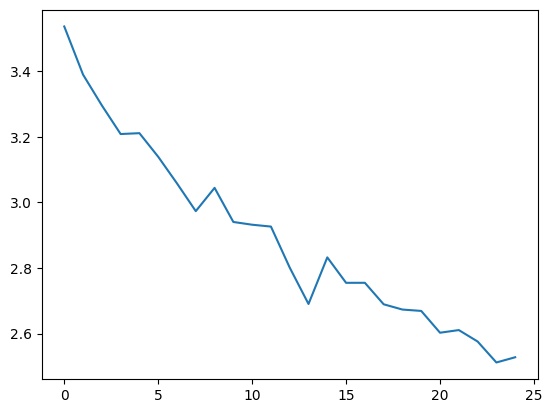

In [121]:
plt.plot(torch.tensor(lossi[1:]).view(-1, 200).mean(1))